# Regularity Components Demo

Per-component view of the NTF decomposition on a filtered host information-flow tensor. Each component gets one row: temporal profile `C[:, r]` | source factor `A[:, r]` | destination factor `B[:, r]` | scores (relevance, periodicity, burstiness, regime).

Header summarises the sweep selection (best `R`, core consistency, explained variance under `R<=25`) and the node-level regime fractions (each node assigned to the regime holding its largest relevance-weighted participation).

## Configuration

In [ ]:
from provenance_explorer.utils.time_conversion import date_string_to_ns_timestamp
from provenance_explorer.plotting import apply_style
from provenance_explorer.analysis.activity_realism.activity_regularity.graph_filters import (
    PersistenceFilter, ActivityFloorFilter, LifespanFilter, TopKFilter,
)
from provenance_explorer.analysis.activity_realism.activity_regularity.regularity_components_plot import (
    RegularityComponentsPlot,
)

apply_style()

DATASET = 'e3'
SUB_DATASET = 'cadets'
HOST_ID = '83C8ED1F-5045-DBCD-B39F-918F0DF4F851'
START_NS = date_string_to_ns_timestamp('2018-04-05 00:00:00')
END_NS = date_string_to_ns_timestamp('2018-04-06 00:00:00')

BIN_WIDTH_NS = 5 * 60 * 1_000_000_000  # 5 minute

# filter pipeline
FILTERS = [
    PersistenceFilter(min_bins=2),
    ActivityFloorFilter(min_events=5),
    TopKFilter(max_nodes=10_000) # Backup to not explode memory or CPU; so far didnt hit
]

# NTF sweep
R_RANGE = list(range(1, 20))
N_INITS = 5
MAX_ITER = 100
TOL = 1e-4
CC_THRESHOLD = 50.0

# regime classification
# concentration = top-mass share on a coarsened temporal profile.
# increase to tolerate wider bursts (sum over more adjacent bins per block).
CONCENTRATION_COARSENING = 5

RUN_KWARGS = dict(
    dataset=DATASET, sub_dataset=SUB_DATASET, host_id=HOST_ID,
    start_ns=START_NS, end_ns=END_NS,
    filters=FILTERS, bin_width_ns=BIN_WIDTH_NS,
    r_range=R_RANGE, n_inits=N_INITS, max_iter=MAX_ITER,
    tol=TOL, cc_threshold=CC_THRESHOLD,
    concentration_coarsening=CONCENTRATION_COARSENING,
)

## Run

Cached per (dataset, sub_dataset, host, window, filter-pipeline-hash). Call `.invalidate(**RUN_KWARGS)` to force re-retrieval.

[cache del]  /mnt/lustre-grete/usr/u20606/provenance-explorer-cache/regularity_components_plot/e3/cadets/83C8ED1F-5045-DBCD-B39F-918F0DF4F851/components_1522886400000000000-1522972800000000000_f4f0b0ac_k5.pkl
[cache miss] Retrieving data for regularity_components_plot...
	[regularity] host=83C8ED1F-5045-DBCD-B39F-918F0DF4F851  filters=['Persistence(min_bins=2)', 'ActivityFloor(min_events=5, quantile=None)', 'TopK(max_nodes=10000)']
	[regularity] N=645  S=289  nnz=14245
R= 1  CC=  100.0%  err=0.6169 expl=61.9%  0.5s
R= 2  CC=  100.0%  err=0.5738 expl=67.1%  0.9s
R= 3  CC=   99.9%  err=0.5519 expl=69.5%  1.2s
R= 4  CC=   97.5%  err=0.5316 expl=71.7%  1.0s
R= 5  CC=  100.0%  err=0.5018 expl=74.8%  1.3s
R= 6  CC=  100.0%  err=0.4837 expl=76.6%  1.3s
R= 7  CC=  -20.7%  err=0.4739 expl=77.5%  1.7s
R= 8  CC=   43.0%  err=0.4631 expl=78.6%  1.4s
R= 9  CC=-1202.4%  err=0.4469 expl=80.0%  1.3s
R=10  CC= -888.4%  err=0.4479 expl=79.9%  1.3s
R=11  CC=-42080.7%  err=0.4217 expl=82.2%  1.5s
R=12  CC

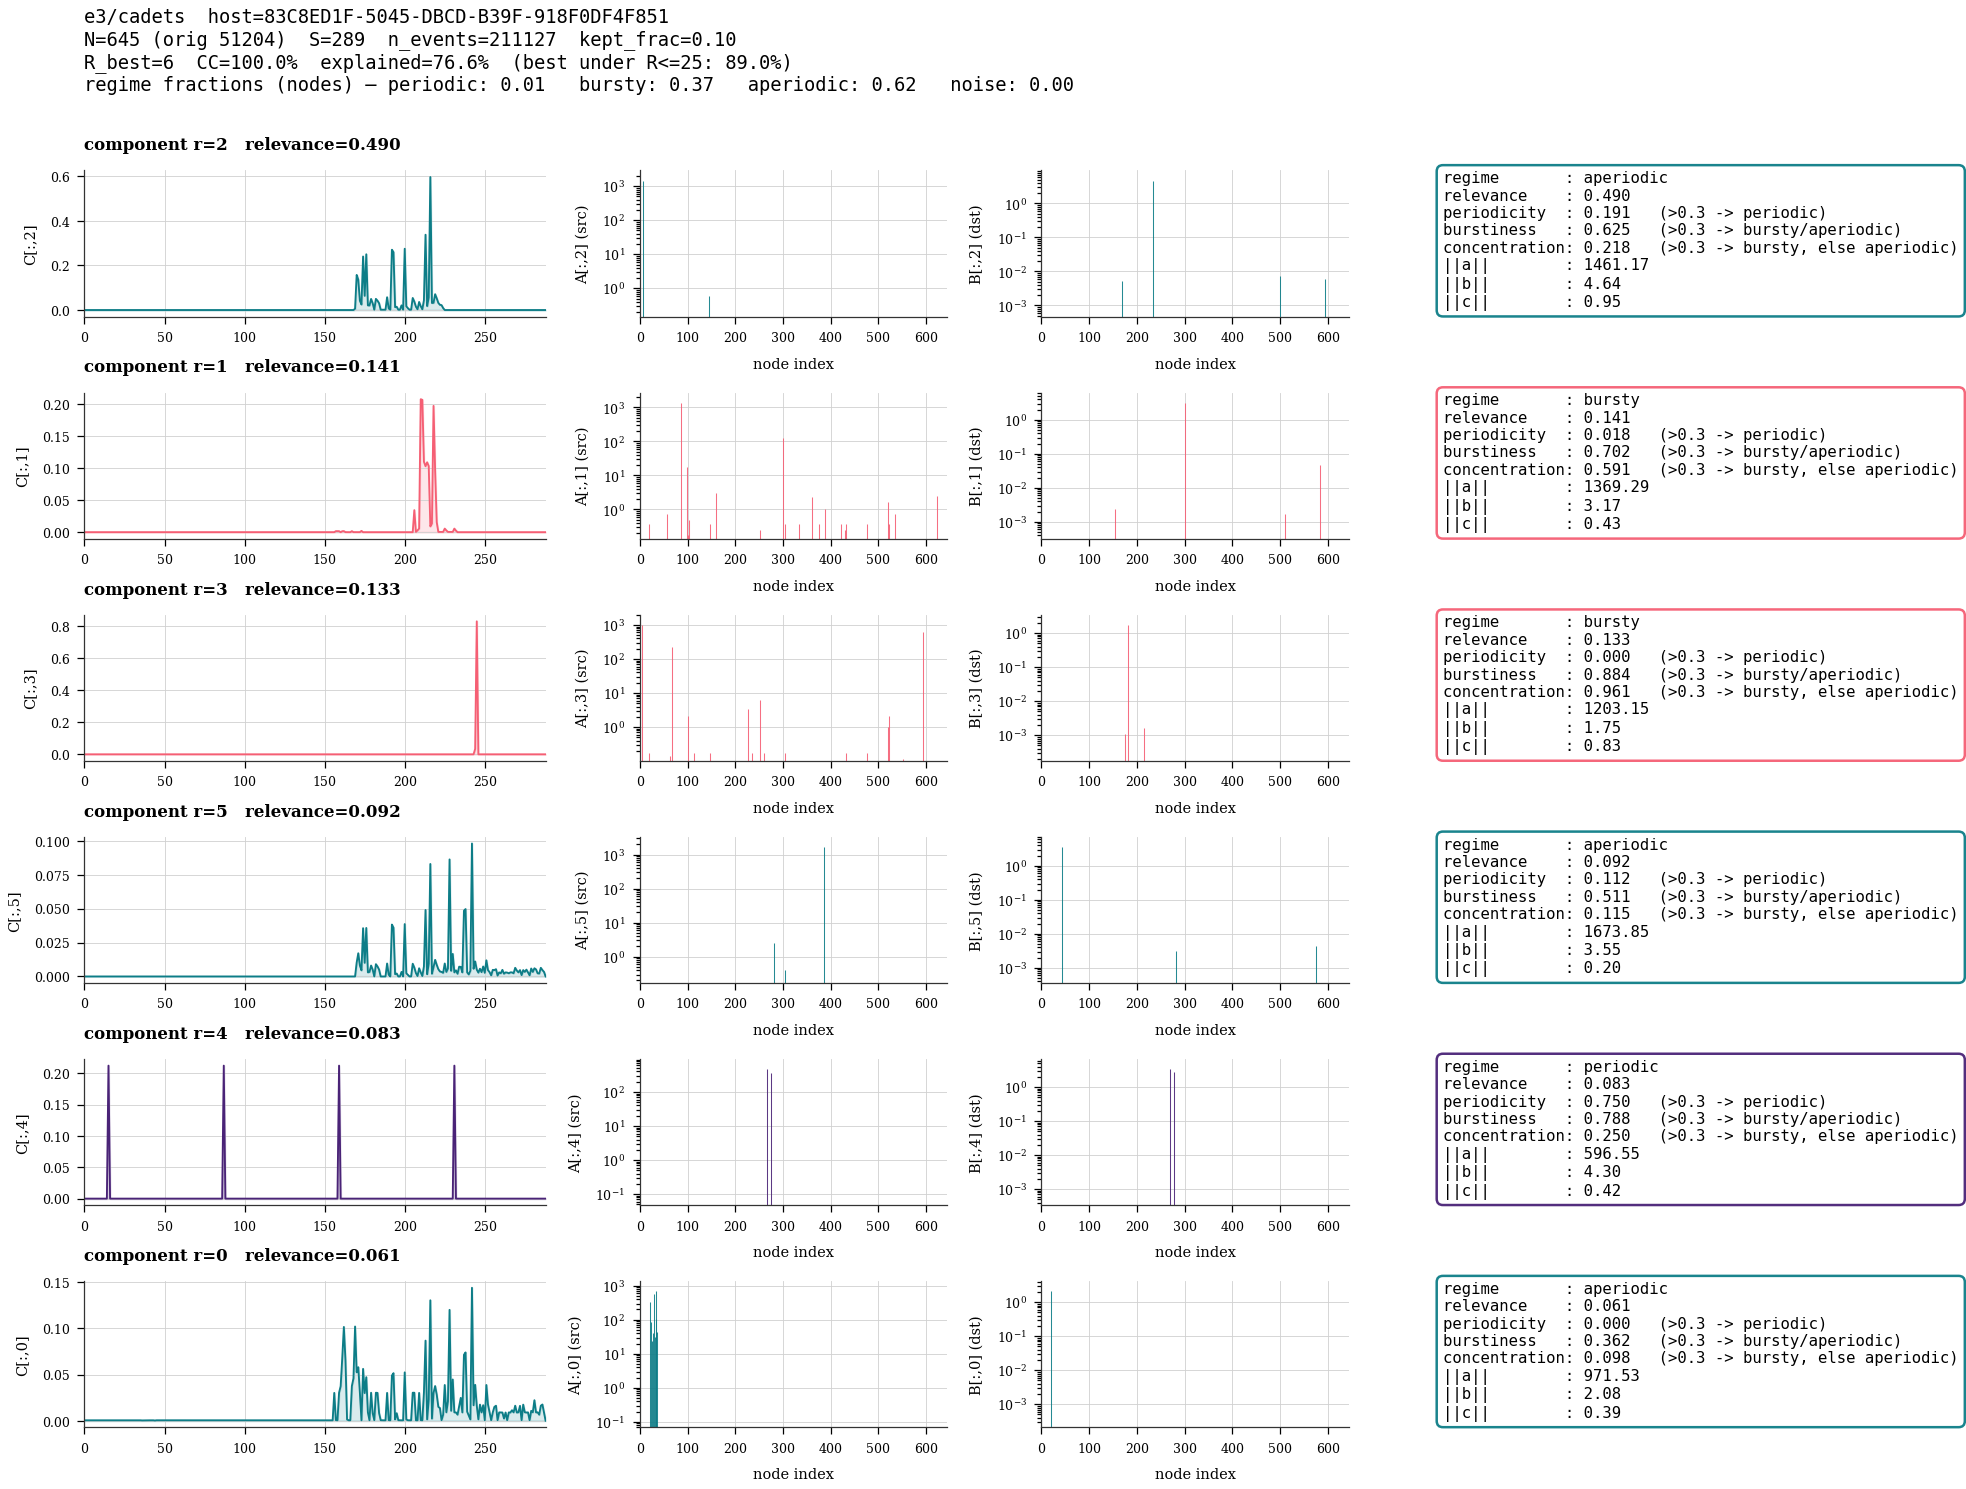

In [2]:
plot = RegularityComponentsPlot()
plot.invalidate(**RUN_KWARGS)
fig = plot.run(**RUN_KWARGS)

## Inspect artefacts

In [3]:
from pprint import pprint
data = plot.load(**RUN_KWARGS)

print('meta:')
pprint(data['meta'])
print()

print('R_best:', data['R_best'], ' CC=', round(data['core_consistency'], 2), ' explained=', round(data['explained_pct'], 2), '%')
print('regime fractions:', data['analysis'].regime_fractions)
print()

display(data['funnel'])
display(data['analysis'].scores.sort_values('relevance', ascending=False))
display(data['sweep_table'])

[cache hit]  /mnt/lustre-grete/usr/u20606/provenance-explorer-cache/regularity_components_plot/e3/cadets/83C8ED1F-5045-DBCD-B39F-918F0DF4F851/components_1522886400000000000-1522972800000000000_f4f0b0ac_k5.pkl
meta:
{'N': 645,
 'N_orig': 51204,
 'S': 289,
 'bin_width_ns': 300000000000,
 'dataset': 'e3',
 'end_ns': 1522972800000000000,
 'fallback_triggered': False,
 'filters': ['Persistence(min_bins=2)',
             'ActivityFloor(min_events=5, quantile=None)',
             'TopK(max_nodes=10000)'],
 'host_id': '83C8ED1F-5045-DBCD-B39F-918F0DF4F851',
 'kept_frac': 0.10300093962311649,
 'max_nodes_fallback': 10000,
 'n_events': 211127,
 'n_events_orig': 2049758,
 'start_ns': 1522886400000000000,
 'sub_dataset': 'cadets'}

R_best: 6  CC= 100.0  explained= 76.6 %
regime fractions: {'periodic': 0.006201550387596899, 'bursty': 0.3705426356589147, 'aperiodic': 0.6232558139534884, 'noise': 0.0}



,stage,filter,N,n_events,frac_nodes_kept,frac_events_kept
0,0,raw,51204,2049758,1.000000,1.000000
1,1,Persistence(min_bins=2),1034,211652,0.020194,0.103257
2,2,"ActivityFloor(min_events=5, quantile=None)",645,211127,0.012597,0.103001
3,3,TopK(max_nodes=10000),645,211127,0.012597,0.103001


,r,relevance,periodicity,burstiness,concentration,regime
2,2,0.489696,0.190897,0.624734,0.217832,aperiodic
1,1,0.140980,0.017611,0.702290,0.590991,bursty
3,3,0.133259,0.000000,0.884485,0.960627,bursty
5,5,0.092267,0.112253,0.510853,0.115003,aperiodic
4,4,0.083212,0.750012,0.788157,0.250000,periodic
0,0,0.060585,0.000000,0.362312,0.098466,aperiodic


,R,rel_error,core_consistency,explained_pct,elapsed_s
0,1,0.616880,1.000000e+02,61.945965,0.468198
1,2,0.573760,1.000000e+02,67.079900,0.851526
2,3,0.551908,9.985791e+01,69.539706,1.151155
3,4,0.531614,9.750874e+01,71.738659,0.981476
4,5,0.501845,1.000000e+02,74.815178,1.294261
5,6,0.483700,1.000000e+02,76.603440,1.264338
6,7,0.473891,-2.066835e+01,77.542720,1.702697
7,8,0.463107,4.298047e+01,78.553236,1.447534
8,9,0.446936,-1.202390e+03,80.024831,1.303056
9,10,0.447919,-8.884197e+02,79.936860,1.346349
